In [9]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\taurm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\taurm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\taurm\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
df = pd.read_csv("sentiment1.csv", header=None)

df.columns = ["id", "topic", "sentiment", "text"]

df.head()

,id,topic,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [12]:
df = df.dropna(subset=['text'])

print(df.shape)

(73996, 4)


In [13]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

In [14]:
df['clean_text'] = df['text'].apply(clean_text)

df[['text','clean_text']].head()

,text,clean_text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder


In [15]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

y = df['sentiment']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
pred = model.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.6825675675675675


In [20]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

  Irrelevant       0.70      0.50      0.59      2696
    Negative       0.72      0.78      0.75      4380
     Neutral       0.63      0.65      0.64      3605
    Positive       0.68      0.73      0.70      4119

    accuracy                           0.68     14800
   macro avg       0.68      0.66      0.67     14800
weighted avg       0.68      0.68      0.68     14800



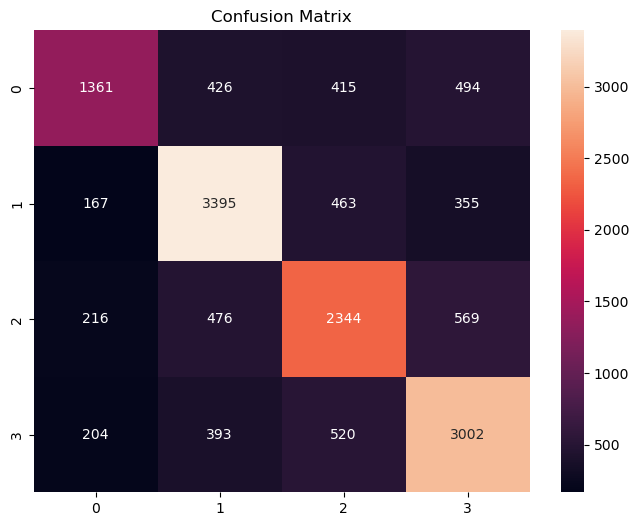

In [21]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [22]:
joblib.dump(model, "model.pkl")

joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [23]:
sample = ["This game is awesome"]

sample_vec = vectorizer.transform(sample)

prediction = model.predict(sample_vec)

print(prediction)

['Positive']


In [24]:
import os

print(os.getcwd())

C:\Users\taurm\Downloads


In [25]:
import os

print("app.py exists:", os.path.exists("app.py"))
print("model.pkl exists:", os.path.exists("model.pkl"))
print("vectorizer.pkl exists:", os.path.exists("vectorizer.pkl"))

app.py exists: True
model.pkl exists: True
vectorizer.pkl exists: True


In [26]:
import os

print("app.py exists:", os.path.exists("app.py"))
print("model.pkl exists:", os.path.exists("model.pkl"))
print("vectorizer.pkl exists:", os.path.exists("vectorizer.pkl"))

app.py exists: True
model.pkl exists: True
vectorizer.pkl exists: True
